In [10]:
import datetime
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import LabelEncoder

In [11]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/mlg-ulb
/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud
    creditcard.csv


In [12]:
train_data = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

In [13]:
train_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
train_data.describe()
train_data.shape

(284807, 31)

In [15]:
train_data.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
train_data.duplicated().sum()


np.int64(1081)

In [17]:
# Check duplicates
print(train_data.duplicated().sum())

# Remove duplicates
train_data = train_data.drop_duplicates()

# Verify
print(train_data.duplicated().sum())
print(train_data.shape)

1081
0
(283726, 31)


In [18]:
train_data["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

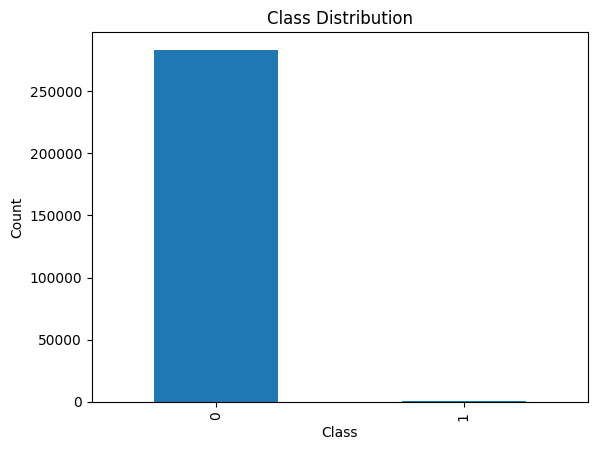

In [19]:
import matplotlib.pyplot as plt

train_data["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [20]:
X = train_data.drop("Class", axis=1)
y = train_data["Class"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   #Scikit-learn keeps the same class proportion in both training and test sets.
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9991365030134283

Confusion Matrix:
[[56641    10]
 [   39    56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [26]:
#ROC-AUC measures how well your model distinguishes between the two classes (Fraud vs Normal) across all possible classification thresholds.

from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9563448965921539


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56641    10]
 [   39    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [28]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    class_weight="balanced", #Scikit-learn automatically gives more importance to the fraud class (Class 1) and less importance to the normal class.
    random_state=42,
    max_iter=1000
)

lr_balanced.fit(X_train, y_train)

y_pred = lr_balanced.predict(X_test)
y_prob = lr_balanced.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import *

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test,y_prob))

[[55258  1393]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC AUC : 0.9658392242808925


In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

In [31]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC AUC :",roc_auc_score(y_test,y_prob))

[[56625    26]
 [   28    67]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC : 0.8524021037395169


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

KeyboardInterrupt: 

In [ ]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC AUC :",roc_auc_score(y_test,y_prob))

In [34]:
!pip install xgboost
from xgboost import XGBClassifier

In [36]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [37]:
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [39]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

[[56647     4]
 [   25    70]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC : 0.9768906388050937


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56647     4]
 [   25    70]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [42]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred = xgb_smote.predict(X_test)
y_prob = xgb_smote.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import *

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

[[56614    37]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.67      0.80      0.73        95

    accuracy                           1.00     56746
   macro avg       0.84      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC : 0.9690156442632591


In [44]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56614    37]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.67      0.80      0.73        95

    accuracy                           1.00     56746
   macro avg       0.84      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746



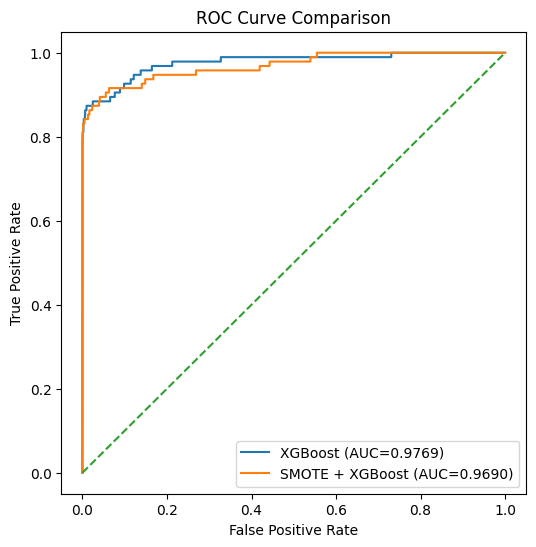

In [45]:
xgb_prob = xgb.predict_proba(X_test)[:, 1]
smote_prob = xgb_smote.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, xgb_prob)
fpr2, tpr2, _ = roc_curve(y_test, smote_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.4f})")
plt.plot(fpr2, tpr2, label=f"SMOTE + XGBoost (AUC={roc_auc_score(y_test, smote_prob):.4f})")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


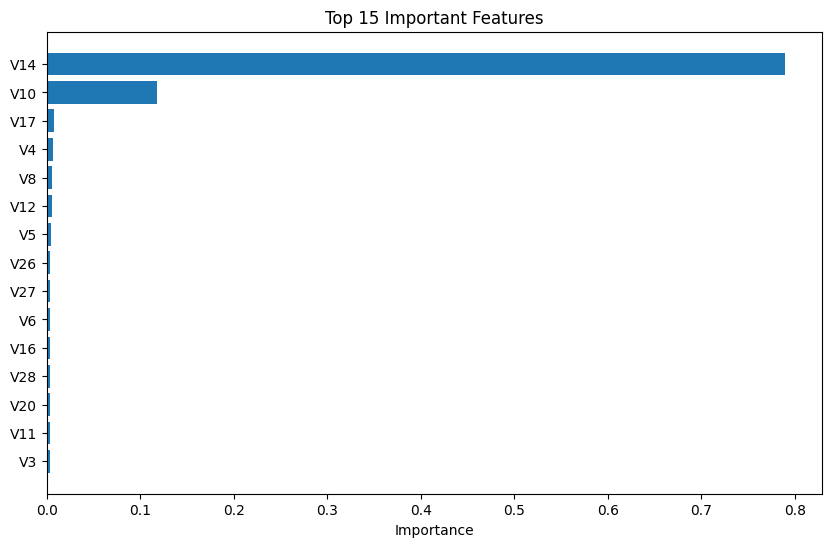

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"][:15], importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

| Model               | Precision |   Recall |       F1 |    ROC-AUC |
| ------------------- | --------: | -------: | -------: | ---------: |
| Logistic Regression |      0.85 |     0.59 |     0.70 |     0.9563 |
| Decision Tree       |       ... |      ... |      ... |     0.8524 |
| Random Forest       |       ... |      ... |      ... |     0.9284 |
| XGBoost             |  **0.95** | **0.74** | **0.83** | **0.9769** |
| SMOTE + XGBoost     |      0.67 | **0.80** |     0.73 |     0.9690 |


In [50]:
import joblib

joblib.dump(xgb_smote, "credit_card_fraud_xgboost.pkl")

['credit_card_fraud_xgboost.pkl']

In [48]:
sample = X_test.iloc[[0]]

prediction = xgb.predict(sample)
probability = xgb.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[9.9999887e-01 1.1108432e-06]]


In [49]:
%whos


Variable                                Type                      Data/Info
---------------------------------------------------------------------------
ConfusionMatrixDisplay                  type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier                  ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
DetCurveDisplay                         type                      <class 'sklearn.metrics._<...>t_curve.DetCurveDisplay'>
DistanceMetric                          type                      <class 'sklearn.metrics._<...>_metrics.DistanceMetric'>
LabelEncoder                            type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression                      type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
PrecisionRecallDisplay                  type                      <class 'sklearn.metrics._<...>.PrecisionRecallDisp

Although SMOTE increased recall, it also increased false positives and reduced overall ROC-AUC